In [1]:
import pandas as pd

grand_sim_df = pd.read_csv('grand_sim_2.csv')
grand_sim_judges_df = pd.read_csv('grand_sim_judges_2.csv')

In [2]:
grand_sim_df

,opening_move,sim,turn,Player,move,move_desc,Random Event,Effect on Player 1,Effect on Player 2
0,Opening Move: I am attacking your position usi...,0,0,Player 1,Deploying a defensive perimeter around the vul...,NaN,NaN,NaN,NaN
1,Opening Move: I am attacking your position usi...,0,0,Player 1,Calling in artillery support to disrupt the ta...,NaN,NaN,NaN,NaN
2,Opening Move: I am attacking your position usi...,0,0,Player 1,Positioning infantry units to create a fallbac...,NaN,NaN,NaN,NaN
3,Opening Move: I am attacking your position usi...,0,0,Player 1,Utilizing reconnaissance to identify the tank ...,NaN,NaN,NaN,NaN
4,Opening Move: I am attacking your position usi...,0,0,Player 1,Requesting air support to provide close air su...,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
363,Opening Move: I am attacking your position usi...,7,4,Player 1,Aggressive Reconnaissance,Immediately dispatch a combined infantry and d...,Localized Chemical Spill,A leak from a damaged supply container release...,The chemical spill disrupts Player 1’s operati...
364,Opening Move: I am attacking your position usi...,7,4,Player 1,Artillery Preparation,Initiate a layered artillery barrage on the id...,Localized Chemical Spill,A leak from a damaged supply container release...,The chemical spill disrupts Player 1’s operati...
365,Opening Move: I am attacking your position usi...,7,4,Player 1,Mobile Assault Force,Dispatch a reinforced assault battalion – inco...,Localized Chemical Spill,A leak from a damaged supply container release...,The chemical spill disrupts Player 1’s operati...
366,Opening Move: I am attacking your position usi...,7,4,Player 1,Electronic Warfare Countermeasures,"Intensify electronic warfare efforts, deployin...",Localized Chemical Spill,A leak from a damaged supply container release...,The chemical spill disrupts Player 1’s operati...


In [3]:

def enirch_moves_with_rand_es(moves,rand_e_list_2):
    """Enrich moves with random events.

    Args:
        moves (list): list of moves
        rand_e_list_2 (list): list of random events

    Returns:
        _type_: _description_
    """
    for rand_e in rand_e_list_2:
        turn = rand_e['turn']
        break_move = next((move for move in moves if move['turn'] == turn and move['Player'] == 'Player 2'), None)
        inser_index = moves.index(break_move)
        
        moves = moves[:inser_index] + [rand_e] + moves[inser_index:]

    return moves


def get_random_events_nodes(grand_sim_df,sim):
    rand_e_df = grand_sim_df.loc[(~grand_sim_df['Random Event'].isna())&(grand_sim_df['sim']==sim)][['Player','Random Event','turn','sim']]
    rand_e_df['Player'] = 'random_event'
    rand_e_df['title'] = rand_e_df.apply(lambda row: f"sim {row['sim']} - turn {row['turn']} - {row['Player']}\n{row['Random Event']}", axis=1)
    rand_e_list = rand_e_df.to_dict(orient = 'records')

    # drop duplicates rand_es
    rand_e_list_2 = []
    for rand_e in rand_e_list:
        if rand_e not in rand_e_list_2:
            rand_e_list_2.append(rand_e)
    return rand_e_list_2

def get_moves(grand_sim_df,sim):
    """Get the nodes for the given turn and simulation.

    Args:
        grand_sim_df (DataFrame): grand simulation dataframe
        turn (int): turn number
        sim (int): simulation number

    Returns:
        _type_: _description_
    """
    df_0 = grand_sim_df[(grand_sim_df['sim'] == sim)]
    
    params = ['title','Player','move','turn','sim','move_desc']
    df_0['title'] = df_0.apply(lambda row: f"sim {row['sim']} - turn {row['turn']} - {row['Player']}\n{row['move']}", axis=1)
    moves = df_0[params].iloc[1:].to_dict(orient = 'records')
    
    return moves



def get_sim_nodes(moves,x):
    move_nodes = []
    for i,move in enumerate(moves):
        
        if move['Player'] == 'Player 1':
            color = 'red'
            move_node = (move['title'], {'color': color, 'coord': (x,i+2)})
        elif move['Player'] == 'Player 2':
            color = 'green'
            move_node = (move['title'], {'color': color, 'coord': (x,i+2)})
        elif move['Player'] == 'random_event':
            color = 'yellow'
            move_node = (move['title'], {'color': color, 'coord': (x,i+2)})
        move_nodes.append(move_node)
        

    edges_list = []
    for i in range(len(move_nodes)-1):
        edges_list.append((move_nodes[i][0],move_nodes[i+1][0]))
        
    return move_nodes, edges_list
    
def get_grand_sim_nodes(grand_sim_df):
    _nodes_list = []
    _edges_list = []
    
    sims = grand_sim_df['sim'].unique().tolist()
    
    central_x = len(sims) // 2
    x_0 = 0 - central_x
    for sim in sims:
        moves = get_moves(grand_sim_df,sim)
        rand_e_list_2 = get_random_events_nodes(grand_sim_df,sim)
        moves = enirch_moves_with_rand_es(moves,rand_e_list_2)
        x = x_0+sim+0.5
        move_nodes, edges_list = get_sim_nodes(moves,x)
        _nodes_list.append(move_nodes)
        _edges_list.append(edges_list)
        
    return _nodes_list, _edges_list

In [4]:
opening_move = grand_sim_df.iloc[0]['opening_move']
opening_move_node = ('opening_move', {'color': 'blue', 'coord': (0, 0)})

_nodes_list, _edges_list = get_grand_sim_nodes(grand_sim_df)

C:\Users\w10\AppData\Local\Temp\ipykernel_17132\2861790768.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_0['title'] = df_0.apply(lambda row: f"sim {row['sim']} - turn {row['turn']} - {row['Player']}\n{row['move']}", axis=1)
C:\Users\w10\AppData\Local\Temp\ipykernel_17132\2861790768.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_0['title'] = df_0.apply(lambda row: f"sim {row['sim']} - turn {row['turn']} - {row['Player']}\n{row['move']}", axis=1)
C:\Users\w10\AppData\Local\Temp\ipykernel_17

C:\Users\w10\AppData\Local\Temp\ipykernel_17132\2061390913.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


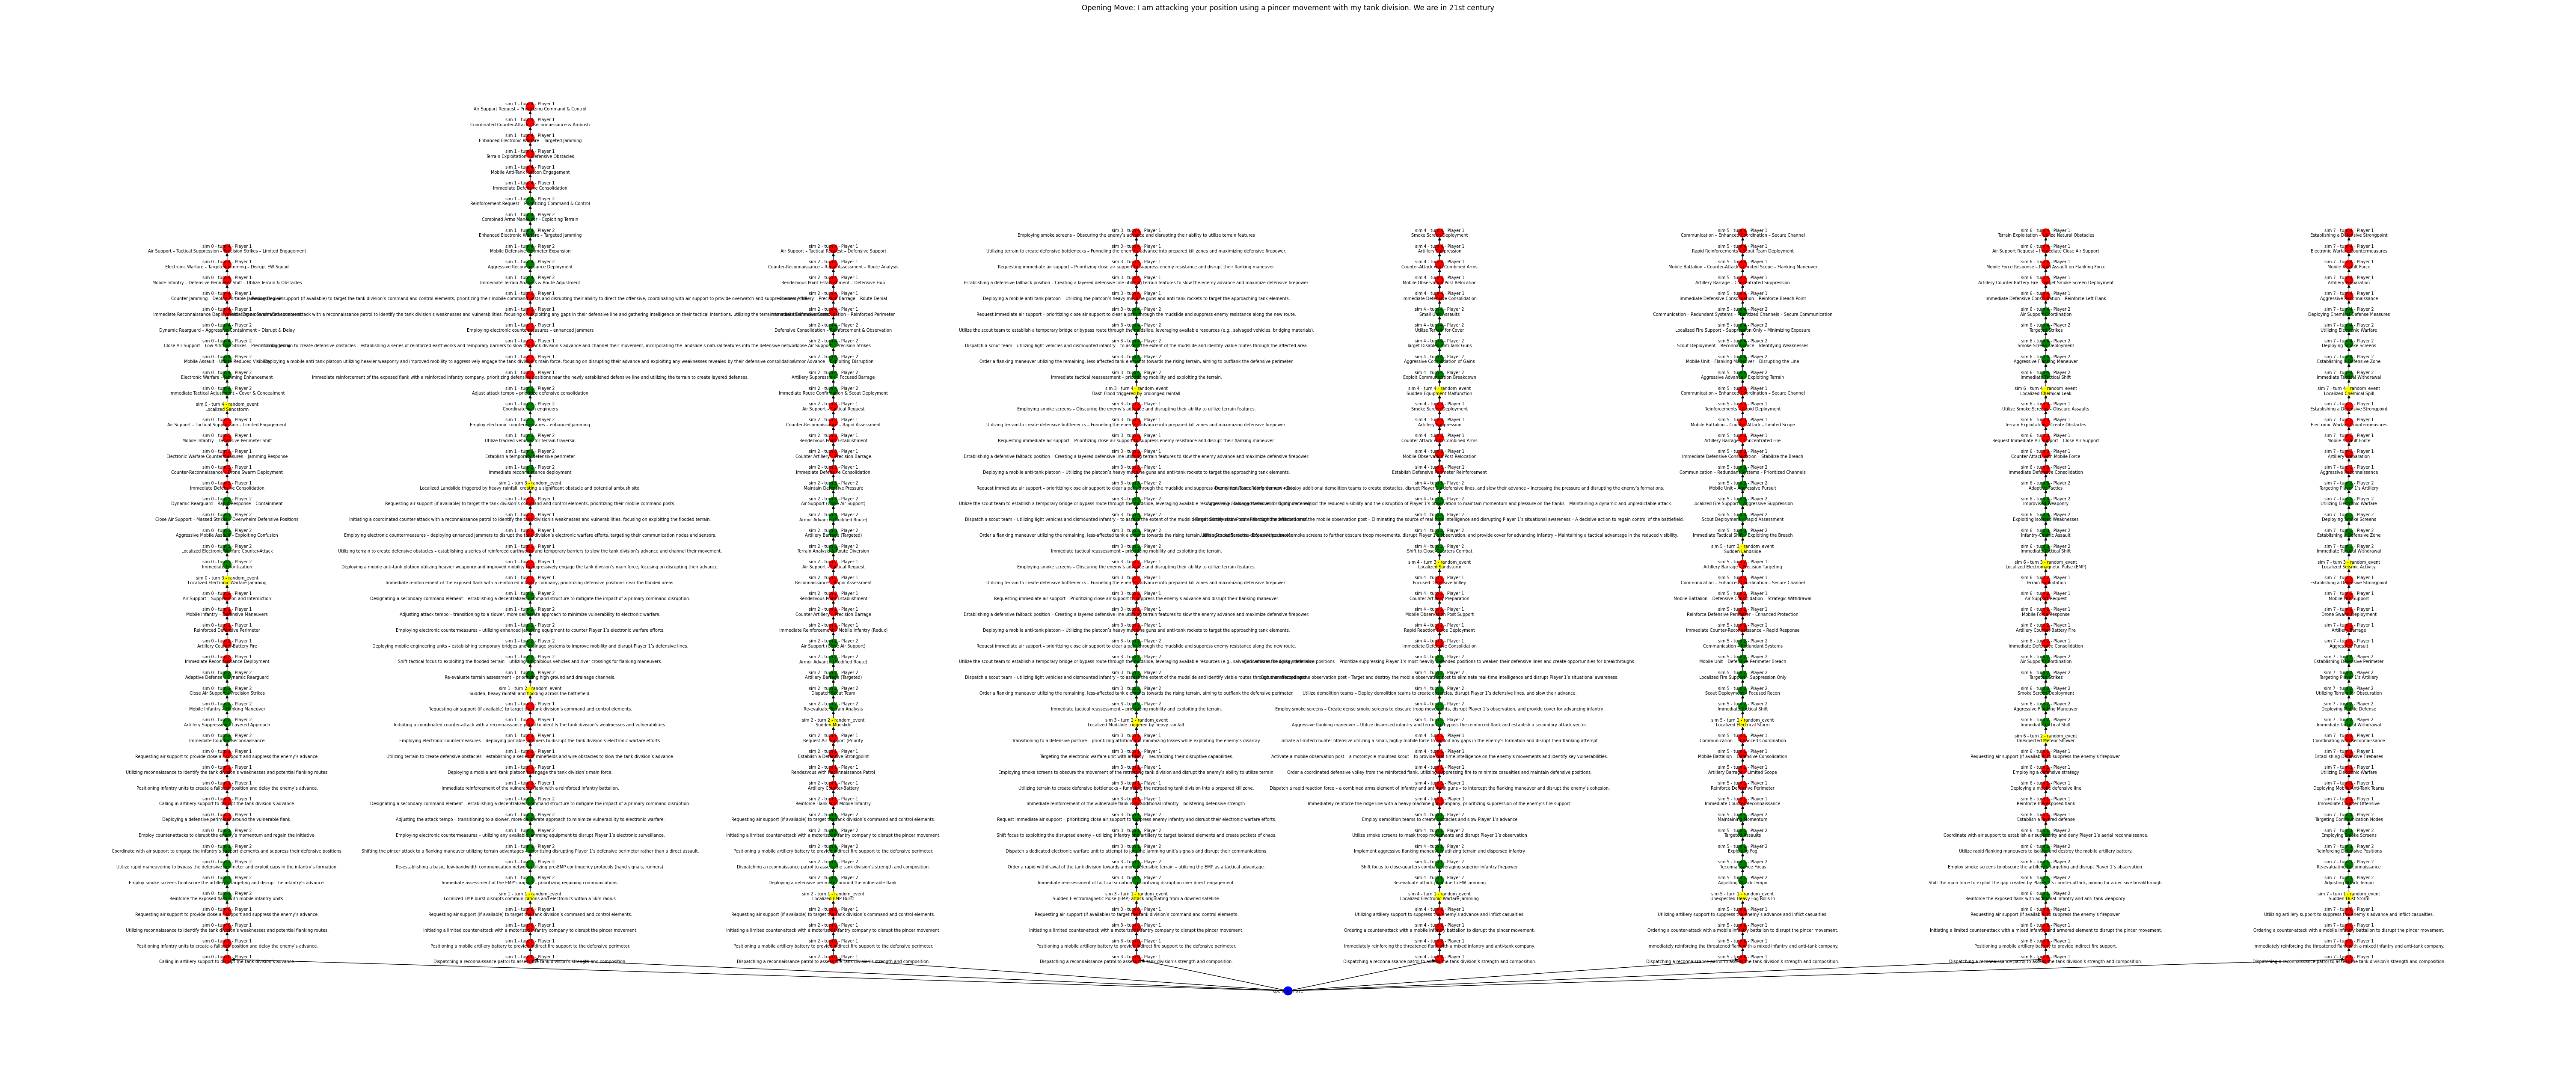

In [5]:

import networkx as nx
import matplotlib.pyplot as plt
# Create root graph H with "person"

H = nx.DiGraph()
H.add_node(opening_move_node[0], color = opening_move_node[1]['color'])
pos = {opening_move_node[0]:(0,0)}
for nodes, edges in zip(_nodes_list, _edges_list):
    # Subgraph F
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    # Merge subgraphs into H
    H.add_nodes_from(G.nodes(data=True))
    H.add_edges_from(G.edges())
    H.add_edge(opening_move_node[0], nodes[0][0])

    colors = [H.nodes[n].get('color') for n in H.nodes]
    
    pos.update({node[0]: node[1]['coord'] for node in nodes})
    
plt.figure(figsize=(60, 25))  # ⬅️ Adjust width and height as needed

nx.draw(
    H,
    pos,
    with_labels=True,
    node_color=colors,
    node_size=200,
    font_size=7,
    arrows=True
)

plt.title(opening_move)
plt.tight_layout()
plt.show()

## Nodes pos per proximity

In [6]:
_nodes_list

[[('sim 0 - turn 0 - Player 1\nCalling in artillery support to disrupt the tank division’s advance.',
   {'color': 'red', 'coord': (-3.5, 2)}),
  ('sim 0 - turn 0 - Player 1\nPositioning infantry units to create a fallback position and delay the enemy’s advance.',
   {'color': 'red', 'coord': (-3.5, 3)}),
  ('sim 0 - turn 0 - Player 1\nUtilizing reconnaissance to identify the tank division’s weaknesses and potential flanking routes.',
   {'color': 'red', 'coord': (-3.5, 4)}),
  ('sim 0 - turn 0 - Player 1\nRequesting air support to provide close air support and suppress the enemy’s advance.',
   {'color': 'red', 'coord': (-3.5, 5)}),
  ('sim 0 - turn 1 - Player 2\nReinforce the exposed flank with mobile infantry units.',
   {'color': 'green', 'coord': (-3.5, 6)}),
  ('sim 0 - turn 1 - Player 2\nEmploy smoke screens to obscure the artillery’s targeting and disrupt the infantry’s advance.',
   {'color': 'green', 'coord': (-3.5, 7)}),
  ('sim 0 - turn 1 - Player 2\nUtilize rapid maneuveri

In [2]:
5*5.61*1.39

38.9895